In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary, get_wmse

In [2]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [3]:
with open("simu2b_data/simu2b_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
df_study = df_study.query("session < 20")  # for testing
df_test = df_test.query("session < 20")

In [4]:
df_study

,session,subj,list,trial,word1,word2,itemno1,itemno2
0,0,101,0,-1,formal,positive,422,759
1,0,101,0,0,skin,careful,930,158
2,0,101,0,1,upon,miss,1086,643
3,0,101,0,2,single,tradition,923,1059
4,0,101,0,3,prove,airport,793,35
...,...,...,...,...,...,...,...,...
9595,19,120,7,54,winter,cause,1135,166
9596,19,120,7,55,master,sent,612,885
9597,19,120,7,56,drop,homes,306,495
9598,19,120,7,57,south,correct,952,234


In [6]:
df_test

,session,subj,list,trial,word1,word2,itemno1,itemno2,type,lag
0,0,101,0,-1,waste,degree,1112,269,rearranged,2
1,0,101,0,0,needed,able,673,2,rearranged,1
2,0,101,0,1,single,clean,923,193,rearranged,3
3,0,101,0,2,train,useful,1061,1089,rearranged,2
4,0,101,0,3,knees,various,552,1095,rearranged,5
...,...,...,...,...,...,...,...,...,...,...
9595,19,120,7,54,square,clean,965,193,rearranged,2
9596,19,120,7,55,relations,extra,830,366,intact,-1
9597,19,120,7,56,captain,baby,154,82,intact,-1
9598,19,120,7,57,leave,near,568,670,intact,-1


In [7]:
sem_mat = np.load("simu2b_data/simu2b_smat.npy")

## Run CMR-IA

In [8]:
# define parameters
params = cmr.make_default_params()
params.update(
    beta_enc=0.5,
    beta_cue=0.5,
    beta_distract=0.9,
    beta_rec_post=0.9,
    gamma_fc=0.5,
    s_fc=0.1,
    c_thresh_assoc=1,
    use_new_context=True,
    use_flexible_thresh=True,
)
params

{'beta_enc': 0.5,
 'beta_rec': 0.5,
 'beta_cue': 0.5,
 'beta_rec_post': 0.9,
 'beta_distract': 0.9,
 'beta_enc_inpair': -1,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 0.1,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 1,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'use_var_enc': False,
 'var_enc_p': None,
 'bad_enc_ratio': None,
 'recog_slope': 1,
 'use_flexible_thresh': True,
 'thresh_rate': 0,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.5,
 'gamma_cf': 0.5}

In [9]:
# task = "Recog"
# mode = "Osth"

# sessions = np.unique(df_study.session)
# list_num = len(np.unique(df_study.list))
# df_thin = df_test[["session", "list", "itemno1", "itemno2"]]
# sess = 3

# # extarct the session data
# pres_mat = df_study.loc[df_study.session == sess, ["itemno1", "itemno2"]].to_numpy()
# pres_mat = np.reshape(pres_mat, (list_num, -1, 2))
# cue_mat = df_thin.loc[df_thin.session == sess, ["itemno1", "itemno2"]].to_numpy()
# cue_mat = np.reshape(cue_mat, (list_num, -1, 2))

# # run CMR for each session
# cmr_m = cmr.CMR(params, pres_mat, sem_mat, source_mat=None, rec_mat=None, ffr_mat=None, cue_mat=cue_mat, task=task, mode=mode)

# cmr_m.run_norm_recog_single_sess()

In [10]:
# run the model
df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat, mode="Osth")
df_simu

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [01:38<00:00,  4.93s/it]

CMR Time: 98.60903763771057


,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob
0,0,0,1112,269,0,0,0.625503,0.647033,0.494618
1,0,0,673,2,1,0,0.813948,0.644880,0.542167
2,0,0,923,193,1,0,0.839005,0.661571,0.544242
3,0,0,1061,1089,1,0,0.841729,0.680769,0.540153
4,0,0,552,1095,1,0,0.831630,0.700238,0.532801
...,...,...,...,...,...,...,...,...,...
9595,19,7,965,193,0,0,0.832482,0.839226,0.498314
9596,19,7,830,366,1,0,0.860186,0.837539,0.505661
9597,19,7,154,82,1,0,0.851156,0.840704,0.502613
9598,19,7,568,670,1,0,0.862989,0.840374,0.505653


In [11]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag
0,0,0,1112,269,0,0,0.625503,0.647033,0.494618,101,-1,waste,degree,rearranged,2
1,0,0,673,2,1,0,0.813948,0.644880,0.542167,101,0,needed,able,rearranged,1
2,0,0,923,193,1,0,0.839005,0.661571,0.544242,101,1,single,clean,rearranged,3
3,0,0,1061,1089,1,0,0.841729,0.680769,0.540153,101,2,train,useful,rearranged,2
4,0,0,552,1095,1,0,0.831630,0.700238,0.532801,101,3,knees,various,rearranged,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,19,7,965,193,0,0,0.832482,0.839226,0.498314,120,54,square,clean,rearranged,2
9596,19,7,830,366,1,0,0.860186,0.837539,0.505661,120,55,relations,extra,intact,-1
9597,19,7,154,82,1,0,0.851156,0.840704,0.502613,120,56,captain,baby,intact,-1
9598,19,7,568,670,1,0,0.862989,0.840374,0.505653,120,57,leave,near,intact,-1


In [12]:
# calculate loss
# s_resp = df_simu["s_resp"].to_numpy()
# yes = df_simu["yes"].to_numpy()
# err = np.nansum(np.abs(s_resp - yes))
# err

In [13]:
if SAVERES:
    df_simu.to_pickle("simu2b_data/simu2b_result.pkl")

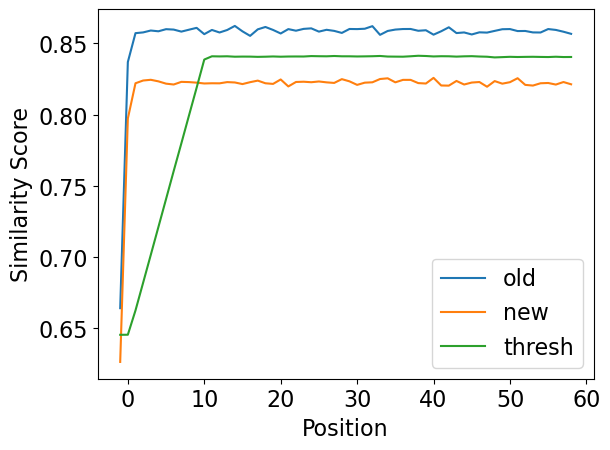

In [14]:
old_csim_pos = df_simu.query("type == 'intact'").groupby("trial").csim.mean()
old_pos = np.unique(df_simu.query("type == 'intact'").trial.to_numpy())
new_csim_pos = df_simu.query("type == 'rearranged'").groupby("trial").csim.mean()
new_pos = np.unique(df_simu.query("type == 'rearranged'").trial.to_numpy())
cthresh_pos = df_simu.groupby("trial").thresh.mean()
pos = np.unique(df_simu.trial.to_numpy())

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.plot(pos, cthresh_pos, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
# plt.ylim(0.8, 0.9)
plt.show()

## Analysis

In [15]:
df_simu["old"] = df_simu.apply(lambda x: 1 if x["type"] == "intact" else 0, axis=1)
df_simu["correct"] = df_simu["s_resp"] == df_simu["old"]
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,old,correct
0,0,0,1112,269,0,0,0.625503,0.647033,0.494618,101,-1,waste,degree,rearranged,2,0,True
1,0,0,673,2,1,0,0.813948,0.644880,0.542167,101,0,needed,able,rearranged,1,0,False
2,0,0,923,193,1,0,0.839005,0.661571,0.544242,101,1,single,clean,rearranged,3,0,False
3,0,0,1061,1089,1,0,0.841729,0.680769,0.540153,101,2,train,useful,rearranged,2,0,False
4,0,0,552,1095,1,0,0.831630,0.700238,0.532801,101,3,knees,various,rearranged,5,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,19,7,965,193,0,0,0.832482,0.839226,0.498314,120,54,square,clean,rearranged,2,0,True
9596,19,7,830,366,1,0,0.860186,0.837539,0.505661,120,55,relations,extra,intact,-1,1,True
9597,19,7,154,82,1,0,0.851156,0.840704,0.502613,120,56,captain,baby,intact,-1,1,True
9598,19,7,568,670,1,0,0.862989,0.840374,0.505653,120,57,leave,near,intact,-1,1,True


### Overall HR and FAR

In [16]:
# get yes rate
df_hrfar = df_simu.groupby(["session", "type"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_hrfar = df_hrfar.pivot(index="session", columns="type", values="yes_rate").reset_index()
df_hrfar["hr"] = df_hrfar["intact"]
df_hrfar["far"] = 1 - df_hrfar["rearranged"]
df_hrfar

type,session,intact,rearranged,hr,far
0,0,0.920833,0.708333,0.920833,0.291667
1,1,0.887500,0.700000,0.887500,0.300000
2,2,0.929167,0.687500,0.929167,0.312500
3,3,0.920833,0.729167,0.920833,0.270833
4,4,0.900000,0.675000,0.900000,0.325000
5,5,0.904167,0.687500,0.904167,0.312500
6,6,0.916667,0.712500,0.916667,0.287500
7,7,0.904167,0.704167,0.904167,0.295833
8,8,0.916667,0.712500,0.916667,0.287500
9,9,0.908333,0.741667,0.908333,0.258333


In [17]:
df_hrfar_plot = pd.melt(df_hrfar, id_vars=["session"], value_vars=["hr", "far"], var_name="type", value_name="yes_rate")
df_hrfar_plot

,session,type,yes_rate
0,0,hr,0.920833
1,1,hr,0.887500
2,2,hr,0.929167
3,3,hr,0.920833
4,4,hr,0.900000
5,5,hr,0.904167
6,6,hr,0.916667
7,7,hr,0.904167
8,8,hr,0.916667
9,9,hr,0.908333


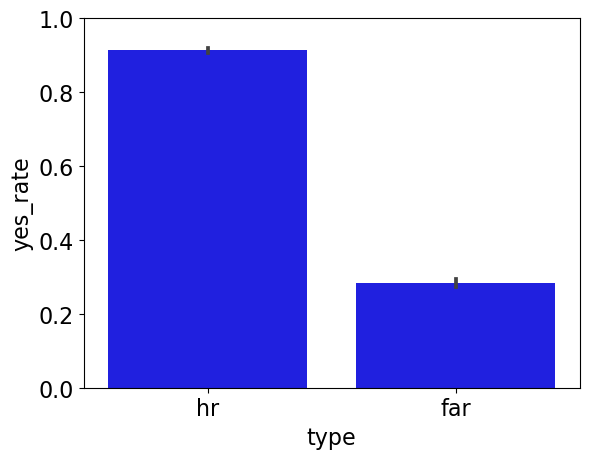

In [18]:
sns.barplot(data=df_hrfar_plot, x="type", y="yes_rate", color="blue")
plt.ylim(0, 1)
plt.show()

### Far with Lag

In [19]:
df_lure = df_simu.query("type == 'rearranged'").copy()
df_farlag = df_lure.groupby(["session", "lag"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_farlag["far"] = 1 - df_farlag["yes_rate"]
df_farlag

,session,lag,yes_rate,far
0,0,1,0.666667,0.333333
1,0,2,0.645833,0.354167
2,0,3,0.687500,0.312500
3,0,4,0.770833,0.229167
4,0,5,0.770833,0.229167
...,...,...,...,...
95,19,1,0.604167,0.395833
96,19,2,0.708333,0.291667
97,19,3,0.750000,0.250000
98,19,4,0.791667,0.208333


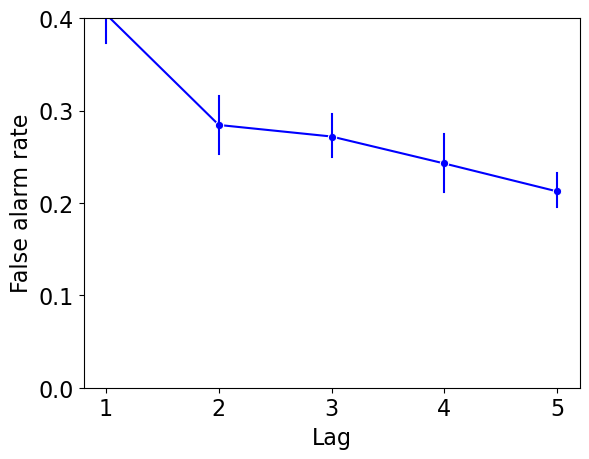

In [20]:
sns.lineplot(
    data=df_farlag,
    x="lag",
    y="far",
    color="blue",
    marker="o",
    err_style="bars",
)
plt.ylim(0, 0.4)
plt.xlim(0.8, 5.2)
plt.xticks(np.arange(1, 6))
plt.yticks(np.arange(0, 0.41, 0.1))
plt.xlabel("Lag")
plt.ylabel("False alarm rate")
plt.show()

### Error Check

In [21]:
# load ground truth
with open("simu2b_data/simu2b_gt.pkl", "rb") as f:
    hr_gt = pickle.load(f)
    hr_std_gt = pickle.load(f)
    far_gt = pickle.load(f)
    far_std_gt = pickle.load(f)
hr_gt, hr_std_gt, far_gt, far_std_gt

(0.5366186381796584,
 0.1633487638481977,
 array([0.21428165, 0.2174274 , 0.21721617, 0.21166567, 0.20021831]),
 array([0.14578635, 0.15351747, 0.16036269, 0.14002328, 0.13892722]))

In [26]:
hr = df_hrfar_plot.query("type == 'hr'").yes_rate.mean()
far = df_farlag.groupby("lag").far.mean().to_numpy()
hr, far

(0.9124999999999999,
 array([0.40416667, 0.284375  , 0.271875  , 0.24270833, 0.2125    ]))

In [27]:
# calculate error
err = 5 * get_wmse(hr_gt, hr, hr_std_gt) + get_wmse(far_gt, far, far_std_gt)
err

28.535029694902626